In [1]:
import pandas as pd
import sqlite3 as sq
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import fiona
import os
import py7zr
import io

In [2]:
archive_path = r"G:\GNRC_GIS_STRUCTURE\UrbanSim\2050\Urbansim_final_run_with_TDM_feedback\2050RTP-Hary-confirmed (block)_recap_with_job_classes.7z"

with py7zr.SevenZipFile(archive_path, mode="r") as archive:
    archive.extract(path=r"C:\temp", targets=["2050RTP-Hary-confirmed (block) - 2023.csv"])

df = pd.read_csv(r"C:\temp\2050RTP-Hary-confirmed (block) - 2023.csv")

In [3]:
df.head(2)

,year,geo_level,geo_level_id,geo_level_name,density_households_acre,density_jobs_acre,density_units_acre,employment_capacity,household_population,household_population_density_acres,...,sector_3,sector_4,sector_5,sector_6,sector_7,sector_8,severe_rent_burden,sum_total_households,sum_total_jobs,sum_total_units
0,2023,block,470831203003000,NaN,0.05,0.0,0.05,3.145802,18.161201,0.10479,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,9.0
1,2023,block,470831203003090,NaN,0.00,0.0,0.00,4.576094,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
col_dict = {'sector_0': 'Other', 'sector_1': 'Service', 'sector_2': 'Retail', 'sector_3': 'Office', 'geo_level_id': 'GEO_ID',
               'sector_4': 'Medical', 'sector_5': 'Industrial', 'sector_6': 'Government', 'sector_7': 
               'Food service', 'sector_8': 'Education', 'household_population': 'hhpop', 'sum_total_households': 'hh', 'sum_total_jobs': 'emp'}

In [5]:
df = df.rename(columns = col_dict)

In [6]:
df_filtered = df[['GEO_ID', 'hhpop', 'hh', 'emp', 'Other', 'Service', 'Retail', 'Office', 'Medical', 'Industrial', 'Government', 'Food service', 'Education']]

In [7]:
df_filtered.head()

,GEO_ID,hhpop,hh,emp,Other,Service,Retail,Office,Medical,Industrial,Government,Food service,Education
0,470831203003000,18.161201,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,470831203003090,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,471190103013047,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,471690902001031,86.982590,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,471190112003048,4.779263,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df_filtered['GEO_ID'] = df_filtered['GEO_ID'].astype(str)

In [9]:
bks = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2024/TABBLOCK20/tl_2024_47_tabblock20.zip")

In [10]:
bks.head(2)

,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry
0,47,089,070600,3022,470890706003022,1000000US470890706003022,Block3022,G5040,R,NaN,S,22984,0,+36.1039140,-083.5416259,0,0,"POLYGON ((-83.54827 36.10252, -83.54801 36.102..."
1,47,089,070400,1069,470890704001069,1000000US470890704001069,Block1069,G5040,R,NaN,S,77296,0,+36.1025952,-083.5587667,7,14,"POLYGON ((-83.56164 36.10215, -83.56158 36.102..."


In [11]:
bks['GEO_ID'] = bks['GEOID20'].astype(str)
bks['COUNTYFP20'] = bks['COUNTYFP20'].astype(str)

In [12]:
bks_join = bks[['GEO_ID', 'geometry', 'COUNTYFP20']]

In [13]:
counties = ['161', '125']
bks_join = bks_join.loc[bks_join['COUNTYFP20'].isin(counties)]

In [14]:
bks_join.head()

,GEO_ID,geometry,COUNTYFP20
3228,471251020054021,"POLYGON ((-87.31318 36.60381, -87.31308 36.604...",125
3229,471251018072010,"POLYGON ((-87.18533 36.51453, -87.18523 36.514...",125
3230,471251008001034,"POLYGON ((-87.34619 36.52826, -87.34594 36.529...",125
3231,471251008001018,"POLYGON ((-87.34527 36.53324, -87.34527 36.533...",125
3232,471251008001033,"POLYGON ((-87.34478 36.53099, -87.34443 36.531...",125


In [15]:
base = bks_join.merge(df_filtered, on = 'GEO_ID', how = 'left')

In [16]:
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 36642 entries, 0 to 36641
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GEO_ID        36642 non-null  str    
 1   hhpop         36642 non-null  float64
 2   hh            36642 non-null  float64
 3   emp           36642 non-null  float64
 4   Other         36642 non-null  float64
 5   Service       36642 non-null  float64
 6   Retail        36642 non-null  float64
 7   Office        36642 non-null  float64
 8   Medical       36642 non-null  float64
 9   Industrial    36642 non-null  float64
 10  Government    36642 non-null  float64
 11  Food service  36642 non-null  float64
 12  Education     36642 non-null  float64
dtypes: float64(12), str(1)
memory usage: 3.6 MB


In [17]:
base.head()

,GEO_ID,geometry,COUNTYFP20,hhpop,hh,emp,Other,Service,Retail,Office,Medical,Industrial,Government,Food service,Education
0,471251020054021,"POLYGON ((-87.31318 36.60381, -87.31308 36.604...",125,80.291611,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,471251018072010,"POLYGON ((-87.18533 36.51453, -87.18523 36.514...",125,25.808022,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,471251008001034,"POLYGON ((-87.34619 36.52826, -87.34594 36.529...",125,3.823411,2.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,0.0
3,471251008001018,"POLYGON ((-87.34527 36.53324, -87.34527 36.533...",125,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,471251008001033,"POLYGON ((-87.34478 36.53099, -87.34443 36.531...",125,6.690969,2.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0


In [19]:
base_geo = gpd.GeoDataFrame(data = base, geometry = base.geometry, crs = bks.crs)

In [20]:
base_geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3838 entries, 0 to 3837
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   GEO_ID        3838 non-null   str     
 1   geometry      3838 non-null   geometry
 2   COUNTYFP20    3838 non-null   str     
 3   hhpop         3838 non-null   float64 
 4   hh            3838 non-null   float64 
 5   emp           3838 non-null   float64 
 6   Other         3838 non-null   float64 
 7   Service       3838 non-null   float64 
 8   Retail        3838 non-null   float64 
 9   Office        3838 non-null   float64 
 10  Medical       3838 non-null   float64 
 11  Industrial    3838 non-null   float64 
 12  Government    3838 non-null   float64 
 13  Food service  3838 non-null   float64 
 14  Education     3838 non-null   float64 
dtypes: float64(12), geometry(1), str(2)
memory usage: 449.9 KB


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

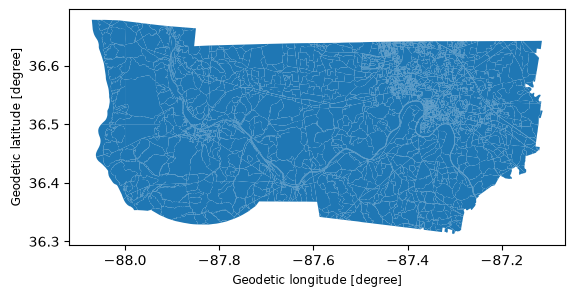

In [21]:
base_geo.plot()